In [2]:
# 03_model_training.ipynb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
import joblib
import json
import mlflow
import mlflow.xgboost

# --- MLflow setup ---
mlflow.set_tracking_uri("file://" + str(Path("mlruns").resolve()))
mlflow.set_experiment("role_classification")

# --- Config ---
INPUT_PATH = "data/features.csv"
MODEL_OUTPUT = "models/role_classifier.pkl"
LABEL_ENCODER_OUTPUT = "models/label_encoder.pkl"
METRICS_OUTPUT = "reports/eval_metrics.json"
REPORT_DIR = Path("reports")
MODEL_DIR = Path("models")

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# --- Load features ---
df = pd.read_csv(INPUT_PATH)
print(f"✅ Loaded {len(df)} samples with {df.shape[1]} columns")

# --- Define feature columns (exclude metadata) ---
meta_cols = ["meeting_id", "speaker_id", "role"]
for c in meta_cols:
    if c not in df.columns:
        raise KeyError(f"Required column missing from features csv: {c}")

FEATURE_COLS = [col for col in df.columns if col not in meta_cols]
TARGET_COL = "role"

# Ensure features numeric
X_all = df[FEATURE_COLS].copy()
X_all = X_all.apply(pd.to_numeric, errors="coerce")
X_all = X_all.fillna(0.0)

# --- Label encoding ---
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df[TARGET_COL].astype(str))
joblib.dump(label_encoder, LABEL_ENCODER_OUTPUT)
print(f"✅ Label encoder saved to {LABEL_ENCODER_OUTPUT}")
label_classes = list(label_encoder.classes_)

# --- Group-aware splitting ---
meetings = df["meeting_id"].unique()
np.random.seed(42)
np.random.shuffle(meetings)

n_meetings = len(meetings)
n_train = max(int(0.7 * n_meetings), 1)
n_val = max(int(0.15 * n_meetings), 1) if n_meetings - n_train >= 2 else max(0, n_meetings - n_train - 1)

train_meetings = meetings[:n_train]
val_meetings = meetings[n_train:n_train + n_val]
test_meetings = meetings[n_train + n_val:]

def filter_by_meetings(df_local, meeting_list):
    return df_local[df_local["meeting_id"].isin(meeting_list)]

train_df = filter_by_meetings(df, train_meetings)
val_df = filter_by_meetings(df, val_meetings)
test_df = filter_by_meetings(df, test_meetings)

use_cv = False
if len(val_df) == 0 or len(test_df) == 0:
    print("⚠️ Falling back to GroupKFold CV (not implemented with MLflow here).")
    use_cv = True
else:
    X_train = train_df[FEATURE_COLS]
    y_train = label_encoder.transform(train_df[TARGET_COL].astype(str))
    X_val = val_df[FEATURE_COLS]
    y_val = label_encoder.transform(val_df[TARGET_COL].astype(str))
    X_test = test_df[FEATURE_COLS]
    y_test = label_encoder.transform(test_df[TARGET_COL].astype(str))
    print(f"SplitOptions → Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# --- Sample weights ---
def compute_sample_weights(y_encoded):
    classes = np.unique(y_encoded)
    weights = compute_class_weight("balanced", classes=classes, y=y_encoded)
    return np.array([dict(zip(classes, weights))[y] for y in y_encoded])

# --- Model config ---
model_params = dict(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    max_depth=5,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# --- MLflow + Training (non-CV path only for now) ---
if not use_cv:
    with mlflow.start_run(run_name="xgboost_v1"):
        # Log params
        mlflow.log_params({
            "model": "XGBoost",
            "max_depth": model_params["max_depth"],
            "n_estimators": model_params["n_estimators"],
            "learning_rate": model_params["learning_rate"],
            "subsample": model_params["subsample"],
            "class_weight_strategy": "balanced",
            "feature_engineering_version": "v3_uncertainty_llm_relative",
            "n_features": len(FEATURE_COLS),
            "train_samples": len(train_df),
            "val_samples": len(val_df),
            "test_samples": len(test_df),
            "calibrated": False  # set to True if you add CalibratedClassifierCV
        })

        print("🚀 Training XGBoost with MLflow tracking...")
        model = XGBClassifier(**model_params)

        sw_train = compute_sample_weights(y_train)
        model.fit(
            X_train, y_train,
            sample_weight=sw_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Evaluate
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

        y_test_decoded = label_encoder.inverse_transform(y_test)
        y_pred_decoded = label_encoder.inverse_transform(y_pred)

        report = classification_report(y_test_decoded, y_pred_decoded, output_dict=True)
        manager_f1 = report.get("manager", {}).get("f1-score", 0.0)
        junior_f1 = report.get("junior", {}).get("f1-score", 0.0)
        other_f1 = report.get("other", {}).get("f1-score", 0.0)
        macro_f1 = f1_score(y_test_decoded, y_pred_decoded, average="macro")

        metrics = {
            "manager_f1": float(manager_f1),
            "junior_f1": float(junior_f1),
            "other_f1": float(other_f1),
            "macro_f1": float(macro_f1)
        }

        # Log metrics
        mlflow.log_metrics(metrics)

        # Log model (sklearn flavor)
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="xgboost_model",
            signature=mlflow.models.infer_signature(X_train, y_pred),
            input_example=X_train.iloc[:1].to_dict(orient="list")
        )

        # Save locally too
        joblib.dump(model, MODEL_OUTPUT)
        print(f"✅ Model saved to {MODEL_OUTPUT}")

        # Log artifacts
        mlflow.log_artifact(LABEL_ENCODER_OUTPUT, "artifacts")
        mlflow.log_artifact("models/tfidf_vectorizer.joblib", "artifacts")
        mlflow.log_artifact("models/tfidf_svd.joblib", "artifacts")
        mlflow.log_artifact(METRICS_OUTPUT, "artifacts")

        # Also save metrics to file (your original behavior)
        with open(METRICS_OUTPUT, "w") as f:
            json.dump(metrics, f, indent=2)
        print(f"✅ Metrics saved to {METRICS_OUTPUT}")

        print("\n📊 Final metrics:")
        print(json.dumps(metrics, indent=2))

else:
    print("⚠️ CV mode not instrumented with MLflow in this version.")
    # (You can extend this later if needed)

✅ Loaded 394 samples with 48 columns
✅ Label encoder saved to models/label_encoder.pkl
SplitOptions → Train: 277, Val: 60, Test: 57
🚀 Training XGBoost with MLflow tracking...


/Users/denuwanwijesinghe/Documents/BSc. Artficial Intellligence/se_project/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [00:17:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/denuwanwijesinghe/Documents/BSc. Artficial Intellligence/se_project/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers Wit

✅ Model saved to models/role_classifier.pkl
✅ Metrics saved to reports/eval_metrics.json

📊 Final metrics:
{
  "manager_f1": 0.8695652173913043,
  "junior_f1": 0.8695652173913043,
  "other_f1": 0.9117647058823529,
  "macro_f1": 0.8836317135549873
}


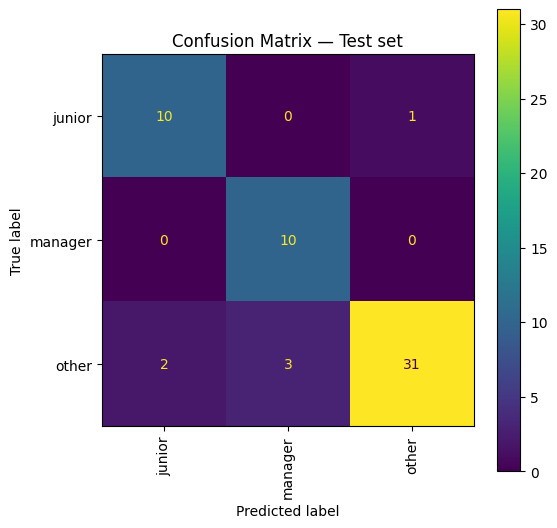

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# y_test_decoded, y_pred_decoded are from your run
cm = confusion_matrix(y_test_decoded, y_pred_decoded, labels=label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix — Test set")
plt.show()


In [4]:
import pandas as pd

# 1) Reload raw data with full_text
raw_df = pd.read_csv("data/labeled_roles.csv")

# 2) Make sure keys exist
assert "meeting_id" in raw_df.columns and "speaker_id" in raw_df.columns
assert "meeting_id" in test_df.columns and "speaker_id" in test_df.columns

# 3) Align test_df with its predictions
#    (X_test, y_test_decoded, y_pred_decoded should already be defined from your training code)
test_with_preds = test_df.copy()
test_with_preds["y_true"] = y_test_decoded
test_with_preds["y_pred"] = y_pred_decoded

# 4) Join original full_text using (meeting_id, speaker_id) as key
raw_keyed = raw_df.set_index(["meeting_id", "speaker_id"])
test_keyed = test_with_preds.set_index(["meeting_id", "speaker_id"])

joined = test_keyed.join(raw_keyed[["full_text"]], how="left")

# 5) Filter only mistakes
errors = joined[joined["y_true"] != joined["y_pred"]].reset_index()

# 6) Show a few example mistakes
errors[["meeting_id", "speaker_id", "full_text", "y_true", "y_pred"]].head(10)


,meeting_id,speaker_id,full_text,y_true,y_pred
0,scrum_053,spk_3,My feature branch diverged too much. Merge con...,junior,other
1,scrum_061,spk_3,I’m debugging why the staging DB connection po...,other,junior
2,scrum_083,spk_3,"Yeah, I’ll pair with you after stand-up. The d...",other,manager
3,scrum_088,spk_3,"If you’re still stuck by noon, just DM me—we’l...",other,manager
4,scrum_100,spk_3,Nice. Make sure it’s behind a feature flag so ...,other,manager
5,scrum_110,spk_1,I was on-call last night—handled an alert abou...,other,junior


In [5]:
import pandas as pd
fi = model.feature_importances_
fi_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": fi})
fi_df.sort_values("importance", ascending=False).head(30)


,feature,importance
6,uncertainty_count,0.153564
9,lm_manager_prob,0.112941
10,word_count_rel,0.095840
14,tfidf_1,0.090082
3,hard_directive_count,0.057068
12,word_count_share,0.038834
16,tfidf_3,0.032501
11,directive_count_rel,0.030679
2,question_count,0.023833
20,tfidf_7,0.023628


/Users/denuwanwijesinghe/Documents/BSc. Artficial Intellligence/se_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/pz/1rnbh6y12_52586kbkygpvnr0000gn/T/ipykernel_50866/3080076581.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=True)
/Users/denuwanwijesinghe/Documents/BSc. Artficial Intellligence/se_project/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` expl

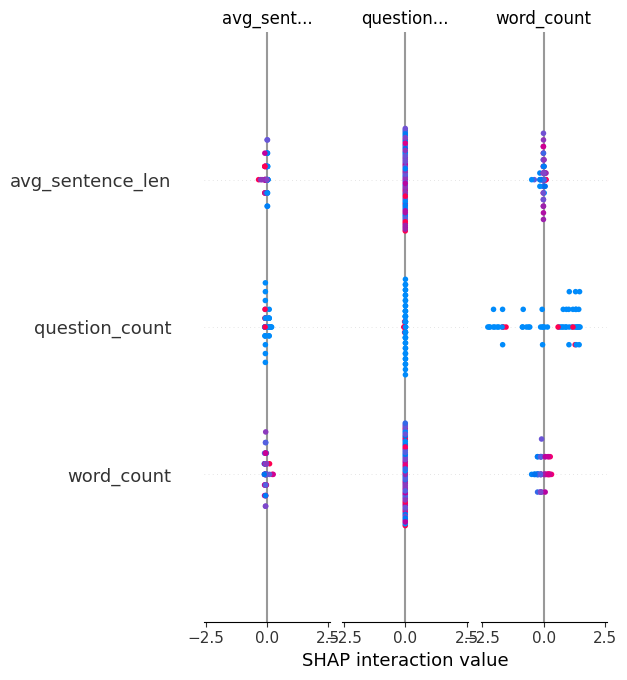

In [6]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # list of arrays for multiclass
# global importance
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=True)


In [7]:
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# base model params (same as you used before)
base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    max_depth=5,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# This will internally do CV on training data and learn calibration
calibrated = CalibratedClassifierCV(
    estimator=base_model,
    method="isotonic",
    cv=5,          # 5-fold CV on the training data
)

# Use only TRAIN data here (not test)
calibrated.fit(X_train, y_train)

# Then evaluate on test
y_pred_cal = calibrated.predict(X_test)
y_proba_cal = calibrated.predict_proba(X_test)

joblib.dump(calibrated, "models/role_classifier_calibrated.pkl")


['models/role_classifier_calibrated.pkl']